In [130]:
#Import Pandas and pyplot
import pandas as pd
import matplotlib.pyplot as plt

In [394]:
#import dataset, preview and clean
df = pd.read_csv(r'mtn_churn.csv')
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.sample(3)


,customer_id,full_name,date_of_purchase,age,state,mtn_device,gender,satisfaction_rate,customer_review,customer_tenure_in_months,subscription_plan,unit_price,number_of_times_purchased,total_revenue,data_usage,customer_churn_status,reasons_for_churn
389,CUST0200,Saidu Tucker,Jan-25,52,Abia,4G Router,Male,4,Very Good,7,25GB Monthly Plan,9000,3,27000,1.26,No,NaN
491,CUST0253,Zainab Blackwell,Feb-25,62,Borno,Mobile SIM Card,Female,4,Very Good,57,3.2GB 2-Day Plan,1000,20,20000,35.57,No,NaN
270,CUST0142,Bala Hood,Feb-25,48,Ekiti,Mobile SIM Card,Female,1,Poor,51,500MB Daily Plan,350,8,2800,198.05,No,NaN


In [703]:
# remove spaces and implement lower cases on all columns
for cols in df.select_dtypes(include=['object', 'string']):
    df[cols] = df[cols].str.strip().str.lower()
df.sample(5)
    

,customer_id,full_name,date_of_purchase,age,state,mtn_device,gender,satisfaction_rate,customer_review,customer_tenure_in_months,subscription_plan,unit_price,number_of_times_purchased,total_revenue,data_usage,customer_churn_status,reasons_for_churn,region,age_group
650,cust0332,david ward,jan-25,58,sokoto,5g broadband router,female,5,excellent,60,60gb monthly broadband plan,14500,11,159500,115.69,yes,high call tarriffs,north west,Middle_Age(45-59)
682,cust0348,boma anderson,feb-25,39,sokoto,mobile sim card,female,4,very good,36,2.5gb 2-day plan,900,8,7200,115.80,no,NaN,north west,Adults(35-44)
498,cust0256,alabo smith,feb-25,36,enugu,4g router,male,3,good,48,25gb monthly plan,9000,2,18000,74.20,yes,better offers from competitors,south east,Adults(35-44)
584,cust0297,bola spencer,jan-25,32,enugu,mobile sim card,male,4,very good,13,16.5gb+10mins monthly plan,6500,19,123500,124.98,yes,poor network,south east,Young_adults(25-34)
355,cust0181,halima walker,feb-25,35,lagos,mobile sim card,female,5,excellent,2,20gb monthly plan,7500,2,15000,98.66,no,NaN,south west,Adults(35-44)


In [707]:
df

,customer_id,full_name,date_of_purchase,age,state,mtn_device,gender,satisfaction_rate,customer_review,customer_tenure_in_months,subscription_plan,unit_price,number_of_times_purchased,total_revenue,data_usage,customer_churn_status,reasons_for_churn,region,age_group
0,cust0001,ngozi berry,jan-25,27,kwara,4g router,male,2,fair,2,165gb monthly plan,35000,19,665000,44.48,yes,relocation,north central,Young_adults(25-34)
1,cust0002,zainab baker,mar-25,16,abuja (fct),mobile sim card,female,2,fair,22,12.5gb monthly plan,5500,12,66000,19.79,yes,better offers from competitors,north central,Youths(16-24)
2,cust0003,saidu evans,mar-25,21,sokoto,5g broadband router,male,1,poor,60,150gb fup monthly unlimited,20000,8,160000,9.64,no,NaN,north west,Youths(16-24)
3,cust0003,saidu evans,mar-25,21,sokoto,mobile sim card,male,1,poor,60,1gb+1.5mins daily plan,500,8,4000,197.05,no,NaN,north west,Youths(16-24)
4,cust0003,saidu evans,mar-25,21,sokoto,broadband mifi,male,1,poor,60,30gb monthly broadband plan,9000,15,135000,76.34,no,NaN,north west,Youths(16-24)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
969,cust0498,shehu harris,jan-25,72,osun,4g router,female,3,good,42,25gb monthly plan,9000,7,63000,8.14,no,NaN,south west,Seniors(60 Above)
970,cust0499,tega hood,mar-25,41,bayelsa,5g broadband router,female,2,fair,20,30gb monthly broadband plan,9000,10,90000,154.13,no,NaN,south south,Adults(35-44)
971,cust0500,oghene hamilton,feb-25,67,kebbi,4g router,male,4,very good,31,165gb monthly plan,35000,15,525000,144.64,yes,high call tarriffs,north west,Seniors(60 Above)
972,cust0500,oghene hamilton,feb-25,67,kebbi,mobile sim card,male,4,very good,31,7gb monthly plan,3500,11,38500,158.49,yes,high call tarriffs,north west,Seniors(60 Above)


In [709]:
#COUNT DISTINCT CUSTOMERS
df['customer_id'].nunique()


496

In [ ]:
# COunt churn Volume
churn = df.groupby('customer_churn_status')['customer_id'].nunique().reset_index(name='count')
churn.columns = ['churn status', 'Count']
churn


,churn status,Count
0,no,350
1,yes,146


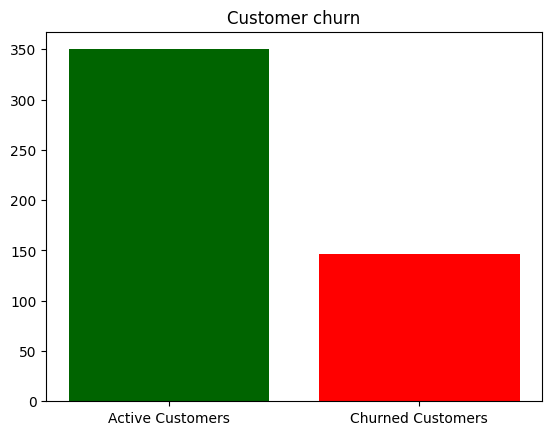

In [247]:
plt.bar(churn['churn status'], churn['Count'], color=["darkgreen","red"])
plt.xticks([1, 0], ["Churned Customers", "Active Customers"])
plt.title('Customer churn')
plt.show()

In [317]:
#Get churn rate
summary = df.groupby("customer_churn_status")["customer_id"].nunique()

churn_rate = 100 * summary["yes"] / summary.sum()
print(f'Churn Rate: {churn_rate:,.2f}')


Churn Rate: 29.44


In [450]:
# Proper table of Customer churn details
unique_customers = df['customer_id'].nunique()
churn_customers = df.loc[df['customer_churn_status'] == 'yes', 'customer_id'].nunique()
overall_churn_rate = round((100 * churn_customers/ unique_customers), 2)
active_customers = unique_customers - churn_customers

churn_table = pd.DataFrame({
    'Details': [ "Unique Customers", "Active Customers", 
                 "Churned Customers", "Overall Churn Rate"],
    'Count':   [unique_customers, active_customers,
                  churn_customers, overall_churn_rate]
})

churn_table


,Details,Count
0,Unique Customers,496.00
1,Active Customers,350.00
2,Churned Customers,146.00
3,Overall Churn Rate,29.44


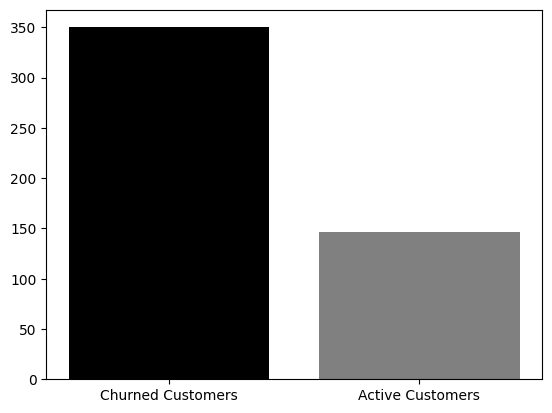

In [350]:
# Plot for active customers and churned customers
plt.bar(churn_table.loc[1:2, 'Details'], churn_table.loc[1:2, 'Count'], color=['black', 'grey'])
plt.xticks([1, 0], ['Active Customers', 'Churned Customers'] )
plt.show()

In [323]:
# #build a chat for customer churn and active customers
# churn_plot = pd.DataFrame({
#     'Status': ["Active Customers", "Churned Customers"],
#     'Count': [active_customers, churn_customers]
# })

# plt.bar(churn_plot['Status'], churn_plot['Count'], color=['black', 'grey'])
# plt.title('Churn')
# plt.show()

In [297]:

genders = df.groupby('gender')['customer_id'].nunique().reset_index(name='count')
genders

,gender,count
0,female,250
1,male,246


Text(0.5, 1.0, 'Gender Distribution')

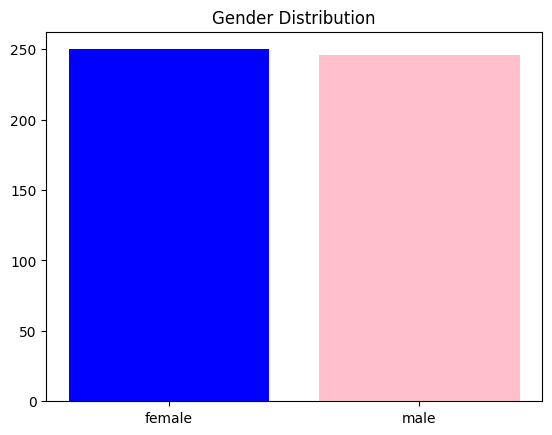

In [281]:
plt.bar(genders['gender'], genders['count'], color=['blue', 'pink'])
plt.title('Gender Distribution')

In [302]:

churn_calc = df[df['customer_churn_status'] == 'yes'].groupby('gender')['customer_id'].nunique().reset_index(name='churn')
churn_calc

,gender,churn
0,female,77
1,male,69


In [421]:
customers = df.groupby('gender')['customer_id'].nunique()
churned_customers = (df[df['customer_churn_status'] == 'yes']
                     .groupby('gender')['customer_id'].nunique())
churn_gender = pd.concat([customers, churned_customers], axis=1)
churn_gender.columns = ['customers', 'churned']
churn_rate = round((100 * churned_customers/customers), 2)
churn_gender['churn_rate'] = churn_rate
churn_gender.reset_index(inplace=True)
churn_gender




,gender,customers,churned,churn_rate
0,female,250,77,30.80
1,male,246,69,28.05


Text(0.5, 1.0, 'Churn rate by gender')

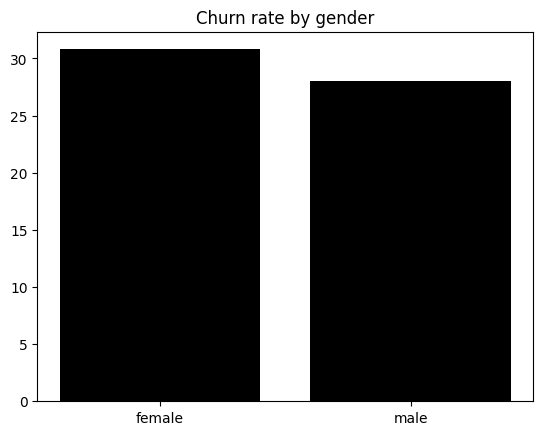

In [353]:
plt.bar(churn_gender['gender'], churn_gender['churn_rate'], color='black')
plt.title("Churn rate by gender")

,Gender,Revenue
0,female,"104,415,650.00"
1,male,"94,932,550.00"


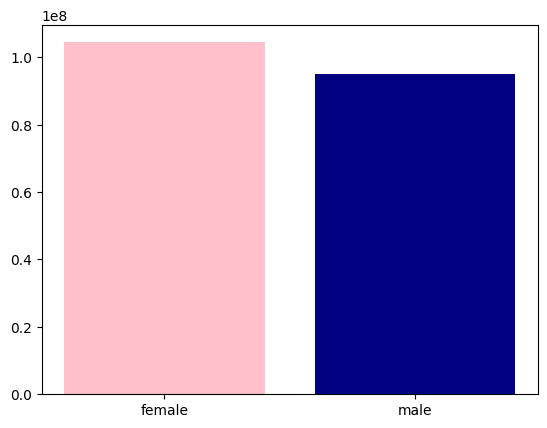

In [354]:
revenue_gender = df.groupby('gender')['total_revenue'].sum().reset_index()
plt.bar(revenue_gender['gender'], revenue_gender['total_revenue'], color=['pink', 'navy'])
revenue_gender['total_revenue'] = revenue_gender['total_revenue'].apply(lambda x: f'{x:,.2f}')
revenue_gender.columns = ['Gender', 'Revenue']
revenue_gender


In [401]:
# Add the region. so we can analyse by regions
region_map = {
    'benue':'North Central','kogi':'North Central','kwara':'North Central',
    'nasarawa':'North Central','niger':'North Central','plateau':'North Central','abuja (fct)':'North Central',

    'adamawa':'North East','bauchi':'North East','borno':'North East',
    'gombe':'North East','taraba':'North East','yobe':'North East',

    'jigawa':'North West','kaduna':'North West','kano':'North West',
    'katsina':'North West','kebbi':'North West','sokoto':'North West','zamfara':'North West',

    'abia':'South East','anambra':'South East','ebonyi':'South East',
    'enugu':'South East','imo':'South East',

    'akwa ibom':'South South','bayelsa':'South South','cross river':'South South',
    'delta':'South South','edo':'South South','rivers':'South South',

    'ekiti':'South West','lagos':'South West','ogun':'South West',
    'ondo':'South West','osun':'South West','oyo':'South West'
}   

df['region'] = df['state'].map(region_map)
df['region'] = df['region'].str.lower()


In [483]:
regions = df.groupby('region')['customer_id'].nunique()
churn_regions = df[df['customer_churn_status'] == 'yes'].groupby('region')['customer_id'].nunique()
region_churn = pd.concat([regions, churn_regions], axis=1)
region_churn.columns = ['Total Customers', 'Churned Customers']
region_churn['churn_rate'] = round((100 * churn_regions)/regions)
region_churn.reset_index(inplace=True)
rccp = region_churn.sort_values(by='Total Customers', ascending=False) #Region Churn Customer Plot
rcp = region_churn.sort_values(by='churn_rate', ascending=False) #Region Churn Customer Plot
region_churn


,region,Total Customers,Churned Customers,churn_rate
0,north central,104,34,33.0
1,north east,95,26,27.0
2,north west,90,26,29.0
3,south east,66,25,38.0
4,south south,70,19,27.0
5,south west,71,16,23.0


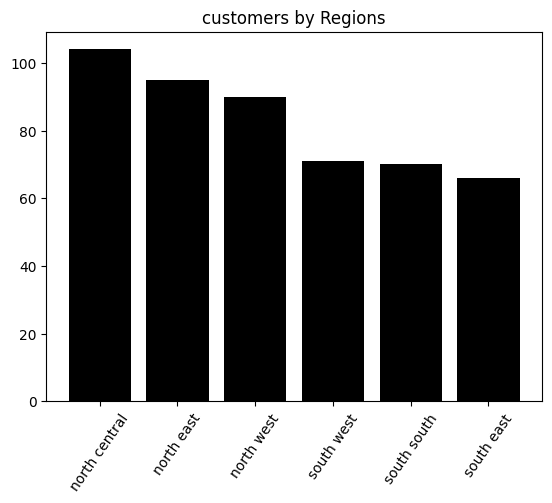

In [475]:
plt.bar(rccp['region'], rccp['Total Customers'], color=['black'])
plt.title("customers by Regions")
plt.xticks(rotation=55)
plt.show()

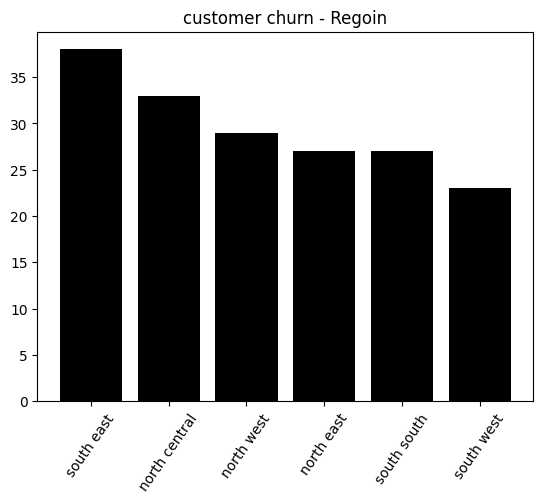

In [482]:
plt.bar(rcp['region'], rcp['churn_rate'], color=['black'])
plt.title("customer churn - Regoin")
plt.xticks(rotation=55)
plt.show()

,region,total_revenue
3,south east,"21,964,800.00"
5,south west,"30,565,100.00"
2,north west,"32,977,950.00"
4,south south,"33,195,100.00"
1,north east,"34,213,700.00"
0,north central,"46,431,550.00"


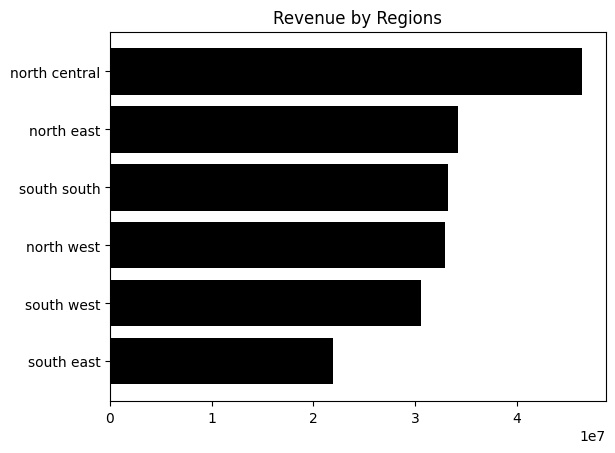

In [ ]:
# Revenue by region Analysis
Total_revenue = df.groupby('region')['total_revenue'].sum().reset_index().sort_values(by='total_revenue', ascending=True)
plt.barh(Total_revenue['region'], Total_revenue['total_revenue'], color='black')
plt.title('Revenue by Regions')
# plt.xticks(rotation=90)
Total_revenue['total_revenue'] = Total_revenue['total_revenue'].apply(lambda x: f'{x:,.2f}')
display(Total_revenue)

In [528]:
# TOP 10 performing states
perfomance = df.groupby(['state', 'region'])['total_revenue'].sum().reset_index().sort_values('total_revenue', ascending=False)
perfomance['total_revenue'] = perfomance['total_revenue'].apply(lambda x: f'{x:,.2f}')

In [529]:
top= perfomance.head(10).reset_index(drop=True)
bottom = perfomance.tail(10).reset_index(drop=True)
top_and_bottom = pd.concat([top, bottom], axis=1, keys=['Top 10', 'Bottom 10'])
# top_and_bottom.columns = ["State"]
top_and_bottom

Top 10                               Bottom 10                 \
         state         region total_revenue      state         region   
0      plateau  north central  9,463,600.00      kebbi     north west   
1        ekiti     south west  9,240,250.00     jigawa     north west   
2         yobe     north east  8,881,700.00       kano     north west   
3          oyo     south west  8,600,350.00     kaduna     north west   
4          edo    south south  7,937,650.00        imo     south east   
5        niger  north central  7,740,000.00  akwa ibom    south south   
6      zamfara     north west  7,248,050.00    adamawa     north east   
7  abuja (fct)  north central  7,180,800.00   nasarawa  north central   
8        borno     north east  7,043,400.00       ondo     south west   
9         osun     south west  6,965,600.00      lagos     south west   

                 
  total_revenue  
0  4,130,000.00  
1  3,962,400.00  
2  3,575,200.00  
3  3,545,500.00  
4  3,537,350.00  
5  3,402,350.00  
6  3,374,000.00  
7  3,361,750.00  
8  2,934,400.00  
9  2,824,500.00

In [556]:
#create an age group column
df['age_group'] = pd.cut(
    df['age'],
    bins=[1,24,34,44,59,100],
    labels=[
        'Youths(16-24)',
        'Young_adults(25-34)',
        'Adults(35-44)',
        'Middle_Age(45-59)',
        'Seniors(60 Above)'
    ]
)

,age_group,Revenue,Customer Distr,Churn,churn Rate
0,Seniors(60 Above),"53,253,500.00",147,41,27.89
1,Middle_Age(45-59),"50,214,050.00",128,34,26.56
2,Young_adults(25-34),"42,890,450.00",101,35,34.65
3,Adults(35-44),"31,062,700.00",67,19,28.36
4,Youths(16-24),"21,927,500.00",53,17,32.08


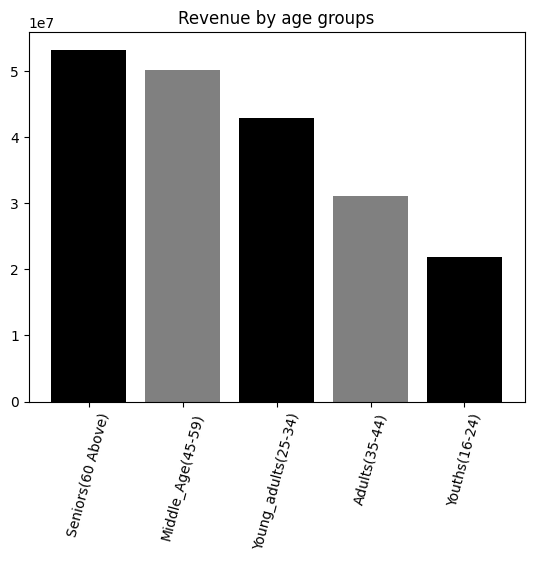

In [617]:
age_groups_revenue = df.groupby('age_group')['total_revenue'].sum()
age_group_distr = df.groupby('age_group')['customer_id'].nunique()
age_group_churn = df[df['customer_churn_status'] == 'yes'].groupby('age_group')['customer_id'].nunique()
age_grp_report = pd.concat([age_groups_revenue, age_group_distr, age_group_churn], axis=1)
age_grp_report.columns = ['Revenue', 'Customer Distr', 'Churn']
age_grp_report['churn Rate']  = round((100 * age_group_churn/ age_group_distr), 2)
age_grp_report.sort_values(by='Revenue', ascending=False, inplace=True)
age_grp_report.reset_index(inplace=True)
plt.bar(age_grp_report['age_group'], age_grp_report['Revenue'], color=['black', 'grey'])
plt.xticks(rotation=75)
plt.title("Revenue by age groups")
age_grp_report['Revenue'] = age_grp_report['Revenue'].apply(lambda x: f'{x:,.2f}')
display(age_grp_report)
plt.show()

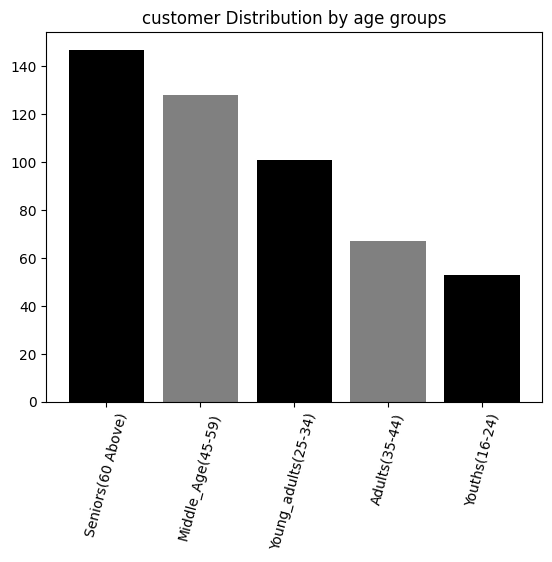

In [616]:
plt.bar(age_grp_report['age_group'], age_grp_report['Customer Distr'], color=['black', 'grey'])
plt.xticks(rotation=75)
plt.title("customer Distribution by age groups")
plt.show()

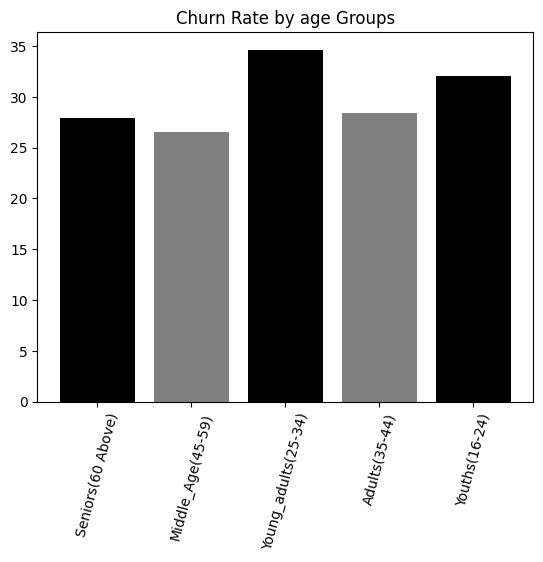

In [615]:
plt.bar(age_grp_report['age_group'], age_grp_report['churn Rate'], color=['black', 'grey'])
plt.title("Churn Rate by age Groups")
plt.xticks(rotation=75)
plt.show()

,mtn_device,total_revenue
1,5g broadband router,"100,818,000.00"
2,broadband mifi,"48,067,500.00"
0,4g router,"37,028,000.00"
3,mobile sim card,"13,434,700.00"


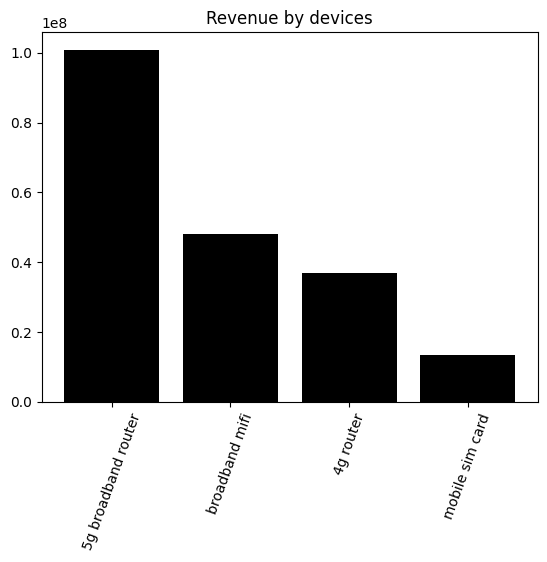

In [718]:
# revenue by MTN DEVICE

mtn_Device = df.groupby('mtn_device')['total_revenue'].sum().reset_index().sort_values(by='total_revenue', ascending=False)
plt.bar(mtn_Device['mtn_device'], mtn_Device['total_revenue'], color='black')
plt.xticks(rotation=70)
plt.title('Revenue by devices')
mtn_Device['total_revenue'] = mtn_Device['total_revenue'].apply(lambda x: f'{x:,.2f}')
mtn_Device


,mtn_device,customer_id
3,mobile sim card,301
1,5g broadband router,229
2,broadband mifi,228
0,4g router,216


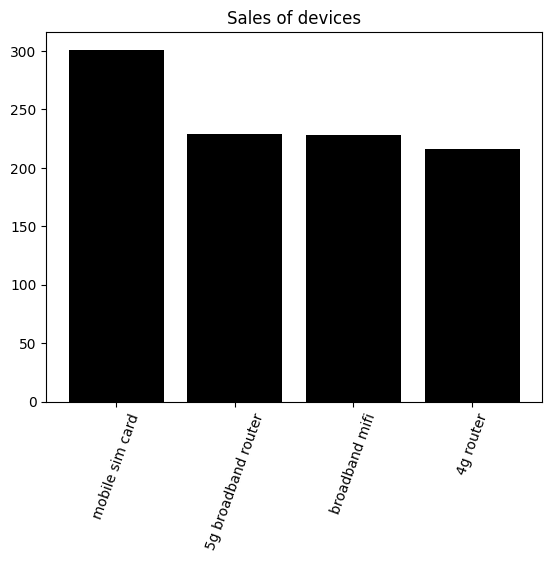

In [717]:
#Count device usage
mtn_Device_count = df.groupby('mtn_device')['customer_id'].count().reset_index().sort_values(by='customer_id', ascending=False)
display(mtn_Device_count)
plt.bar(mtn_Device_count['mtn_device'], mtn_Device_count['customer_id'], color='black')
plt.xticks(rotation=70)
plt.title("Sales of devices")
plt.show()

In [ ]:
#device popularity by regions
df.pivot_table(
    values='customer_id',
    index='region',
    columns=['mtn_device'], 
    aggfunc='count')

mtn_device,4g router,5g broadband router,broadband mifi,mobile sim card
region,,,,
north central,43,50,47,60
north east,43,40,44,50
north west,42,44,42,55
south east,25,22,35,43
south south,33,38,29,49
south west,30,35,31,44


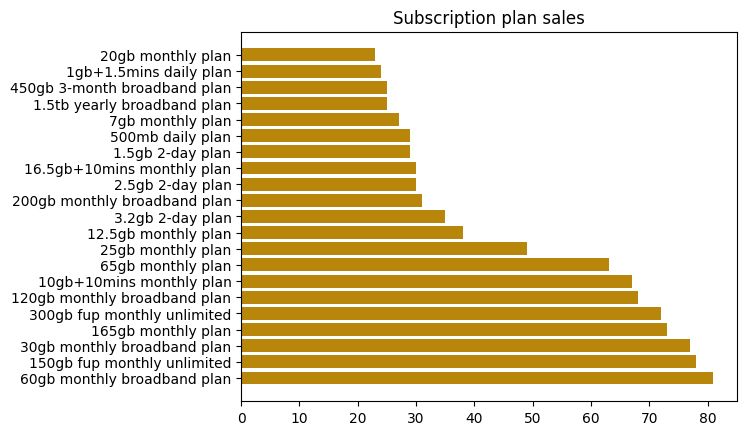

,subscription_plan,customer_id
18,60gb monthly broadband plan,81
5,150gb fup monthly unlimited,78
15,30gb monthly broadband plan,77
7,165gb monthly plan,73
14,300gb fup monthly unlimited,72


,subscription_plan,customer_id
20,7gb monthly plan,27
1,1.5tb yearly broadband plan,25
16,450gb 3-month broadband plan,25
8,1gb+1.5mins daily plan,24
11,20gb monthly plan,23


In [721]:
subs_count = df.groupby('subscription_plan')['customer_id'].count().reset_index().sort_values(by='customer_id', ascending=False)
plt.barh(subs_count['subscription_plan'], subs_count['customer_id'], color='darkgoldenrod')
plt.title('Subscription plan sales')
plt.show() #plot

display(subs_count.head(5)) #top 5
display(subs_count.tail(5)) #bottom 5


,subscription_plan,total_revenue
1,1.5tb yearly broadband plan,"40,200,000.00"
7,165gb monthly plan,"26,250,000.00"
14,300gb fup monthly unlimited,"25,770,000.00"
5,150gb fup monthly unlimited,"18,980,000.00"
16,450gb 3-month broadband plan,"18,375,000.00"


,subscription_plan,total_revenue
13,3.2gb 2-day plan,"377,000.00"
9,2.5gb 2-day plan,"300,600.00"
0,1.5gb 2-day plan,"170,400.00"
8,1gb+1.5mins daily plan,"116,500.00"
17,500mb daily plan,"112,700.00"


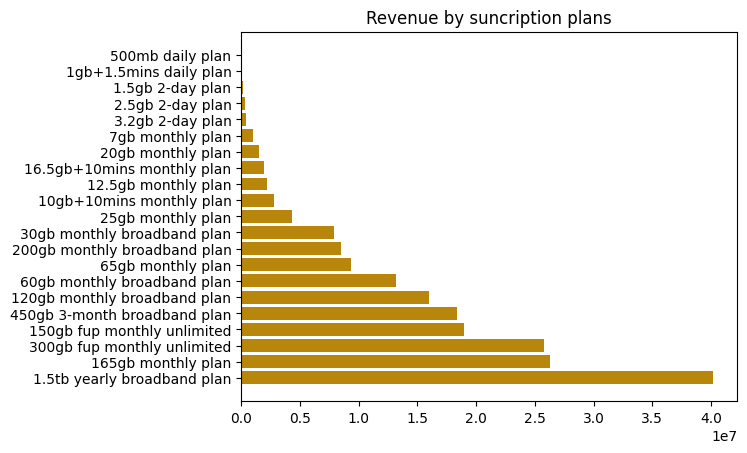

In [719]:
#Subcription plans by revenue
subs = df.groupby('subscription_plan')['total_revenue'].sum().reset_index().sort_values(by='total_revenue', ascending=False)
plt.barh(subs['subscription_plan'], subs['total_revenue'], color='darkgoldenrod')#plot
plt.title('Revenue by suncription plans')
subs['total_revenue'] = subs['total_revenue'].apply(lambda x: f'{x:,.2f}')
display(subs.head(5))
display(subs.tail(5))

In [667]:
# which plans are the top spenders buying?
top_subs = df[df['age'] > 45].groupby('subscription_plan')['customer_id'].count().reset_index().sort_values(by='customer_id', ascending=False).head(5)
top_subs.columns =['Subs', 'Purchase']
display(top_subs)

,Subs,Purchase
5,150gb fup monthly unlimited,52
15,30gb monthly broadband plan,44
18,60gb monthly broadband plan,43
14,300gb fup monthly unlimited,41
4,120gb monthly broadband plan,40


In [665]:
# which plans are the top spenders buying?
botttom_subs = df[df['age'] < 25].groupby('subscription_plan')['customer_id'].count().reset_index().sort_values(by='customer_id', ascending=False).head(5)
botttom_subs.columns =['Subs', 'Purchase']
display(botttom_subs)

,Subs,Purchase
2,10gb+10mins monthly plan,15
4,120gb monthly broadband plan,8
19,65gb monthly plan,6
3,12.5gb monthly plan,6
17,500mb daily plan,6


In [729]:
# Customer Review analysis
review = df[df['customer_churn_status'] == 'yes'].groupby(['customer_review', 'satisfaction_rate'])['customer_id'].nunique().reset_index().sort_values(by='satisfaction_rate')
review.columns = ['Review', 'Satisfaction Score', 'Churn']
display(review)

,Review,Satisfaction Score,Churn
3,poor,1,26
1,fair,2,30
2,good,3,27
4,very good,4,32
0,excellent,5,31


In [731]:
# Customer Review analysis for all customers
review_all = df.groupby(['customer_review', 'satisfaction_rate'])['customer_id'].nunique().reset_index().sort_values(by='satisfaction_rate')
review_all.columns = ['Review', 'Satisfaction Score', 'Churn']
display(review_all)

,Review,Satisfaction Score,Churn
3,poor,1,98
1,fair,2,96
2,good,3,107
4,very good,4,109
0,excellent,5,86


In [705]:
churn_reason = df[df['customer_churn_status'] == 'yes'].groupby(['reasons_for_churn'])['customer_id'].nunique().reset_index().sort_values(by='customer_id', ascending=True)
churn_reason.columns = ['Reason', 'Churn']
display(churn_reason)

,Reason,Churn
6,relocation,15
2,fast data consumption,18
4,poor customer service,18
1,costly data plans,20
5,poor network,20
3,high call tarriffs,26
0,better offers from competitors,29


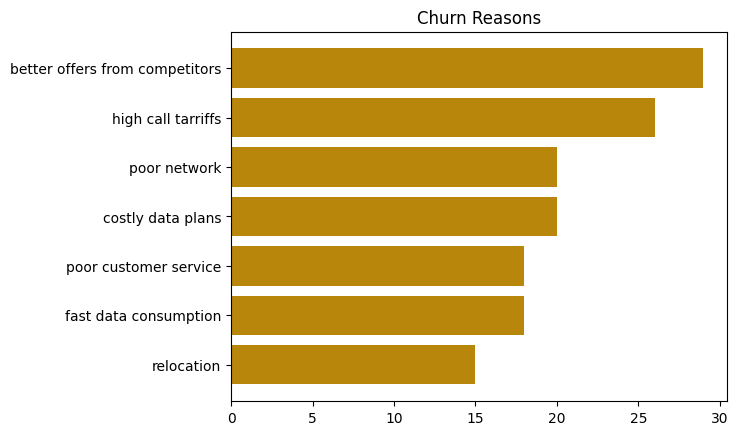

In [706]:
plt.barh(churn_reason['Reason'], churn_reason['Churn'], color='darkgoldenrod')
plt.title("Churn Reasons")
plt.show()

In [ ]:
# churn reason for the youths
churn_reason = df[(df['customer_churn_status'] == 'yes') & (df['age_group'] == 'Youths(16-24)')].groupby(['reasons_for_churn'])['customer_id'].nunique().reset_index().sort_values(by='customer_id', ascending=True)
churn_reason.columns = ['Reason', 'Churn']
display(churn_reason)

,Reason,Churn
3,high call tarriffs,2
2,fast data consumption,2
4,poor network,2
1,costly data plans,3
0,better offers from competitors,4
5,relocation,4


In [ ]:
# satisfaction rate for the youths
review = df[(df['customer_churn_status'] == 'yes') & (df['age_group'] == 'Youths(16-24)')].groupby(['customer_review', 'satisfaction_rate'])['customer_id'].nunique().reset_index().sort_values(by='satisfaction_rate')
review.columns = ['Review', 'Satisfaction Score', 'Churn']
display(review)

,Review,Satisfaction Score,Churn
3,poor,1,4
1,fair,2,6
2,good,3,4
0,excellent,5,3
